### Checking if William's data matches miepython

The purpose of test_silicon_for_comparison.ipynb file is to replicate a CSV similar to silicon_σabs.csv, so that whenever it loads the data both match correctly, on this notebook the data is loaded as is and we work with the dataframes only, no nanoparticles properties are calculated in this notebook is purely to compare both programs.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load both William's data and miepython's data
Wabs = pd.read_csv("silicon_σabs.csv")  # William's data
t = pd.read_csv("test.csv")             # miepython estimation

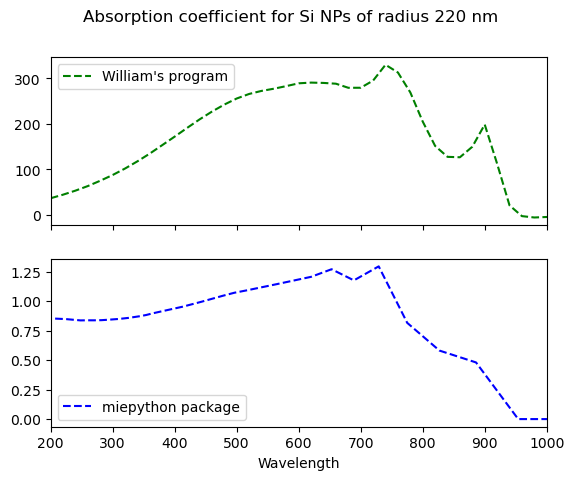

In [77]:
# Automate legend and title stuff for quick calculation and image generation
size_idx = 45                                    # Index selection, it chooses a radius of the data and compares it --- Vary this index to check how different sizes behave on both programs, max 50.
size = float(Wabs.columns[size_idx])            # gets size as float for plotting
t_cross_section = (np.pi * (size*1e-18))        # particle cross section

# Get data, divide William's data by the cross section, miepython already deals with it as efficiencies
abs_W = Wabs.iloc[:, size_idx]/t_cross_section
abs_miepython = t.iloc[:, size_idx]

# Plotting
fig, (ax1, ax2) = plt.subplots(2, sharex = True)
fig.suptitle(f'Absorption coefficient for Si NPs of radius {round(size)} nm')
ax1.plot(Wabs.iloc[:,0], abs_W, "--g", label = "William's program")
ax2.plot(t.iloc[:,0], abs_miepython, "--b", label = "miepython package")
plt.xlabel("Wavelength")
plt.xlim(200, 1000)
ax1.legend()
ax2.legend()
plt.show()

# New Scatting Checking
> William realised that the data provided may have error. Wants to use a correct scatting file. 

### `MiePython` Calculated Spectra
Used `calculate_spectra_table.py` to generate the *Wavelength vs Radii* spectra table for silicon from `materails/silicon.csv` (Amorphous Silicon - Pierce 1972) -> generated file `test_sca_amor_silicon_Pierce_1972.csv`

### William Spectra (reference)
(can rename this - it is rich assuming William has the "reference spectra")

The reference spectra table is `silicon_σsca - [400 - 900 nm] - Air - amorphous - Pierce 1972.csv`. It was calculated using the same refractive index file (interpolated in a similar manner to `src.lambda_interpolate`) in a air medium ($n=1.0003$) uisng a `wolfram` code (Mathematica).

> Please note the reference file is the scatting spectra for the silicon particles, not the absorption for the cells above!

What I (William) expect to see is that both the refercne and `MiePython` Calculated Spectra should match.

Text(0.5, 1.0, 'Scatting coefficient of amorphous silicon (r=100 nm)')

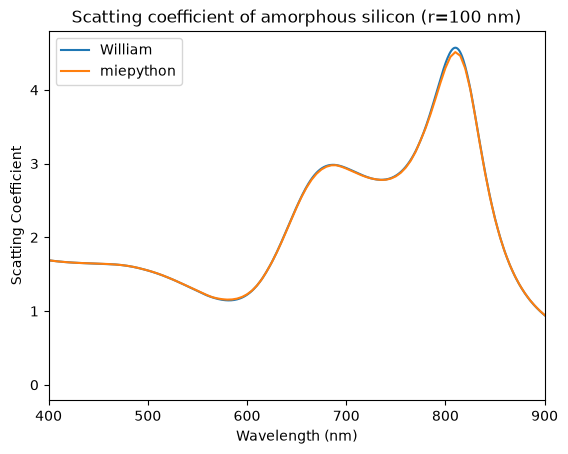

In [28]:
miepython_df = pd.read_csv('test_sca_amor_silicon_Pierce_1972.csv', index_col=0)
miepython_df.columns = miepython_df.columns.astype(float) *1e3  # in nm
miepython_df.index = miepython_df.index.astype(float) # in nm

william_df = pd.read_csv('silicon_σsca - [400 - 900 nm] - Air - amorphous - Pierce 1972.csv', index_col=0)
william_df.columns = william_df.columns.astype(float) # in nm
william_df.index = william_df.index.astype(float) # in nm

radius = 100 # nm
t_cross_section = (np.pi * (radius*1e-16)) # could be the wrong scale

fig, ax = plt.subplots(1)
ax.plot(william_df.index, william_df[float(radius)]/t_cross_section, label='William')
ax.plot(miepython_df.index, miepython_df[float(radius)], label='miepython')

ax.legend()
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Scatting Coefficient")
ax.set_xlim(400,900)
ax.set_title(f'Scatting coefficient of amorphous silicon (r={radius} nm)')

From this plot I am for the most part confident that `miepython` has accurate calculations of overall Mie calculations when the refrative index data is interperlated.

In [ ]:
# TODO: check the individual MD, ED, MQ and EQ positional peaks